In [12]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
# Create data
import numpy as np
import os
from os.path import join
import matplotlib.pyplot as plt
from itertools import product
from utils.save_load import load

def load_client_acc(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "list_client_acc.pt"))

def load_client_size(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "list_model_size.pt"))

def load_client_time(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "self.list_client_time.pt"))


def load_acc(exp, cs=False):
    c = load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "self.list_acc.pt"))
    if c[0] == 0:
        return c[1:]
    else:
        return c

def load_real_time(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "time.pt"))

def load_time(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "self.time"))

def load_ms(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "model_size.pt"))

def load_fed_avg_acc(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "fed_avg_acc.pt"))

def load_fed_avg_loss(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "fed_avg_loss.pt"))

def load_model_G(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "model_G.pt"))

def load_list_client_time(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "self.list_client_time.pt"))

def load_list_client_density(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "self.list_client_density"))
    
def load_train_number(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "self.train_number"))

def find_level(s):
    for level in ['high', 'medium', 'low']:
        if level in s:
            return level
    return None

def get_acc_time(acc,time):
    target_acc = [0.83]
    n = 10
    cv_acc = np.convolve(acc, np.ones((n,)) / n, mode='valid')
    cv_time = np.convolve(time, np.ones((n,)) / n, mode='valid')
        # 创建一个字典来存储每个阈值的第一次超过的索引
    exceedances = {threshold: None for threshold in target_acc}
    ac_time = [None]*3
    i = 0
    # 遍历序列，检查每个元素是否超过任何未标记的阈值
    for index, value in enumerate(cv_acc):
        for threshold in target_acc:
            # 如果当前值大于阈值，并且这个阈值还没有找到超过的位置
            if value > threshold and exceedances[threshold] is None:
                exceedances[threshold] = int(cv_time[index])
                ac_time[i] = int(cv_time[index])
                i = i+1
    return ac_time



# 自定义格式化函数，将 x 轴单位改为 10^3
def format_kilo(x, _):
    return f"{int(x / 10000)}"


def get_time_acc(acc,time,time_line):
    windows = 3
    for index, T in enumerate(time):
        if T>time_line :
            break;
    import numpy as np
    # index = int(10000/25)


    b_mean = np.mean(acc[index-windows:index+windows])*100
    b_std = np.std(acc[index-windows:index+windows])*100

    return [time_line,round(b_mean, 2),f"{b_std:.2g}"]
old_name = None
def plt_photo_acc(exp, exp_legend, fig_name='PR-FL', y_lim=[0.70, 0.90], x_lim=[1, 80000], cov = False):
    import matplotlib.pyplot as plt
    import os
    from os.path import join
    
    # Define the interval for markers
    interval = 15  # You can adjust this value to change the marker density
    # config2 = type("Config", (object,), {"EXP_NAME": "experiment_name"})  # 示例配置
    

    # Create a new figure
    figsize = (7, 5.25)
    plt.figure(figsize=figsize)
    ac_time = {}
    from matplotlib.ticker import FuncFormatter
    # Iterate through all experiments to plot each curve
    for i in range(len(exp)):
        exp_name = exp[i]
        try:
            # Load data
            acc = load_acc(exp_name)
            fed_avg_acc = load_fed_avg_acc(exp_name)
            if  np.mean(acc[-100:-1])>np.mean(fed_avg_acc[-100:-1]):
                fed_avg_acc = acc
            else:
                fed_avg_acc = fed_avg_acc
                
                
            
            if 'heterofl' in exp_name or  'fedrolex' in exp_name:
                level = find_level(exp_name)
                ep2 = 'Time_'+ level
                time = load_time(ep2)
                min_len = min(len(time), len(fed_avg_acc))
                fed_avg_acc = fed_avg_acc[:min_len]
                time = time[:min_len]
                
            elif 'fjord' in exp_name:
                
                level = find_level(exp_name)
                ep2 = 'Time_'+ level
                time = load_time(ep2)
                if len(fed_avg_acc) < 200:
                    time = time[::2]
                min_len = min(len(time), len(fed_avg_acc))
                fed_avg_acc = fed_avg_acc[:min_len]
                time = time[:min_len]
                
            else:
                time = load_time(exp_name)
                
            min_len = min(len(time), len(fed_avg_acc))
            fed_avg_acc = fed_avg_acc[:min_len]
            time = time[:min_len]
            cv_acc = np.convolve(fed_avg_acc, np.ones((n,)) / n, mode='valid')
            cv_time = np.convolve(time, np.ones((n,)) / n, mode='valid')
            if not cov: 
                cv_acc = fed_avg_acc
                cv_time = time


            # if 'fed_avg' in exp_name and 'mask_fed_avg' not in exp_name:
            #     interval =1
            # print(len(cv_time), len(cv_acc))
            plt.plot(cv_time, cv_acc, linestyle=linestyles[i ], color=colors[i], linewidth=1, label=exp_legend[i],marker=markers[i],markevery=interval)
        except FileNotFoundError:
            print(f"Skipping {exp_name}. Client selection = {client_sel}.")
    # for key in ac_time.keys():
    #     print(key, ":", ac_time[key])
    # Set labels and axis limits
    plt.xlabel("Time ($10^4$ s)",fontsize=16)
    plt.ylabel("Test Accuracy",fontsize=16)
    plt.xticks(fontsize=14)  # 增大 x 轴刻度字体
    plt.yticks(fontsize=14)  # 增大 y 轴刻度字体
    plt.xlim(x_lim)
    plt.ylim(y_lim)
    # 使用 FuncFormatter 应用自定义格式
    plt.gca().xaxis.set_major_formatter(FuncFormatter(format_kilo))
    # Add legend
    # Add legend
    plt.legend(
        frameon=False,
        loc="lower right",
        bbox_to_anchor=(1, 0),
        fontsize= 'x-large',
        ncol=2
    )

    # Set grid
    plt.grid(linestyle="--", color='black', lw=0.5, alpha=0.5)

    # Ensure result directories exist and save the figure
    result_path = join("results", config.EXP_NAME)
    fig_path = join(result_path, "figs")

    if not os.path.isdir(fig_path):
        os.makedirs(fig_path)

    plt.savefig(join(fig_path, fig_name + ".png"), dpi=600, bbox_inches='tight')  # Save as PNG format
    plt.show()

def get_time_acc(acc,time,time_line):
    windows = 5
    for index, T in enumerate(time):
        if T>time_line :
            break;
    import numpy as np
    # index = int(10000/25)
    b_mean = np.mean(acc[index-windows:index+windows])*100
    b_std = np.std(acc[index-windows:index+windows])*100
    return [time_line,round(b_mean, 2),f"{b_std:.2g}"]

def plt_time_acc(exp, time_line):
    time_acc = {}
    for i in range(len(exp)):
        exp_name = exp[i]
        try:
            # Load data
            fed_avg_acc = load_fed_avg_acc(exp_name)
            acc = load_acc(exp_name)
            if  np.mean(acc[-100:-1])>np.mean(fed_avg_acc[-100:-1]):
                fed_avg_acc = acc
            else:
                fed_avg_acc = fed_avg_acc
                
                
            if 'heterofl' in exp_name or  'fedrolex' in exp_name:
                level = find_level(exp_name)
                ep2 = 'Time_'+ level
                time = load_time(ep2)
                min_len = min(len(time), len(fed_avg_acc))
                fed_avg_acc = fed_avg_acc[:min_len]
                time = time[:min_len]
                

            elif 'fjord' in exp_name:
                
                level = find_level(exp_name)
                ep2 = 'Time_'+ level
                time = load_time(ep2)
                if len(fed_avg_acc) < 200:
                    time = time[::2]
                print(time[:5])
                min_len = min(len(time), len(fed_avg_acc))
                fed_avg_acc = fed_avg_acc[:min_len]
                time = time[:min_len]
                
            else:
                time = load_time(exp_name)
                
            time_acc[exp_name] = get_time_acc(fed_avg_acc,time,time_line)
        except FileNotFoundError:
            print(f"Skipping {exp_name}. Client selection = {client_sel}.")
    import pandas as pd
    import os
    from openpyxl import load_workbook
    for k, v in time_acc.items():
        print(k,v)
    file_path = config.EXP_NAME+'.xlsx'
    sheet_name = 'Sheet1'
    
    # 构造你的数据（你已有的 time_acc）
    df_new = pd.DataFrame([
        {
            'Name': k,
            'Time': v[0],
            'Accuracy': v[1],
            'Std': float(v[2]) if isinstance(v[2], str) else v[2]
        }
        for k, v in time_acc.items()
    ])
    
    # 如果文件存在，读取旧数据；否则创建空DataFrame
    if os.path.exists(file_path):
        df_old = pd.read_excel(file_path, sheet_name=sheet_name)
        df_combined = pd.concat([df_old, df_new], ignore_index=True)
    
        # 以追加模式打开并替换已有 sheet
        with pd.ExcelWriter(file_path, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
            df_combined.to_excel(writer, sheet_name=sheet_name, index=False)
    else:
        # 如果文件不存在，直接写入新数据
        df_new.to_excel(file_path, index=False)
        
dataset_name = "ImageNet100"
import configs.imagenet100 as config
client_sel = False
time_lim = (-1000, 60000)
acc_lim = (0.0, 0.9)
lottery_ticket_acc_lim = (0.7, 0.9)
n = 15



result_path = join("results", config.EXP_NAME)
if not os.path.isdir(f"results/{config.EXP_NAME}/figs"):
    os.makedirs(f"results/{config.EXP_NAME}/figs")
fig_path = join(result_path, "figs")
linestyles = [(0, (2, 2)),'-', '--', '-.', ':', (0, (5, 1)), (0, (3, 5, 1, 5)), ]
colors     = ['red','blue', 'green', 'purple', 'orange', 'brown', 'pink']  # 第7个 red = 你的方法
markers    = [ '^','o', '*', 'D', 's', 'p', 'v',]  # 第7个 '^' = 你的方法


In [3]:
import os
list = os.listdir(result_path)
list = sorted(list)

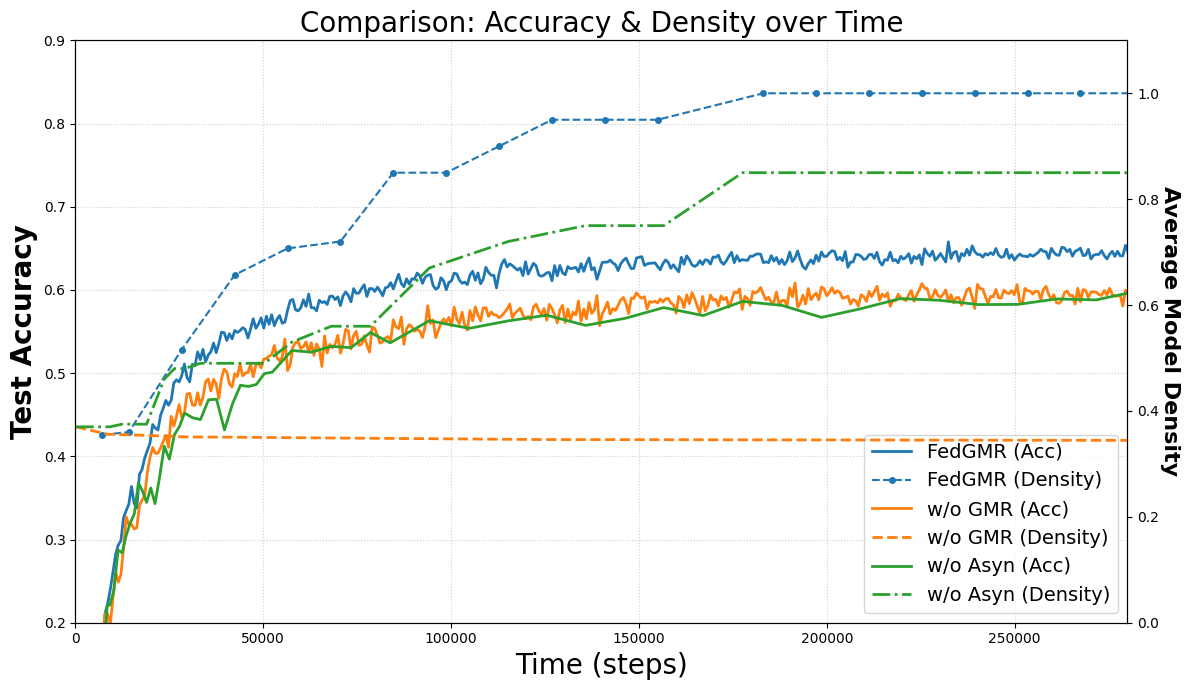

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------------------------------------------------------
# 1. 数据准备 (Data Preparation)
# -----------------------------------------------------------------------------

raw1 = """
7206	[501, 487, 501, 501, 500, 501, 501, 501, 500, 500]	1.00,0.87,0.50,0.49,0.19,0.20,0.10,0.10,0.05,0.05
14255	[1001, 986, 1001, 1001, 1000, 1001, 1001, 1001, 999, 797]	1.00,0.87,0.50,0.49,0.19,0.20,0.10,0.10,0.05,0.10
28339	[2001, 1984, 2001, 2001, 1739, 1869, 1554, 1631, 1494, 1182]	1.00,0.87,0.50,0.49,0.50,0.50,0.50,0.50,0.10,0.20
42438	[3001, 2983, 3001, 2650, 2073, 2217, 1767, 1845, 1804, 1392]	1.00,0.87,0.50,1.00,1.00,0.50,0.50,0.50,0.20,0.50
56496	[4001, 3983, 3596, 3147, 2285, 2565, 1980, 2058, 2054, 1506]	1.00,0.87,1.00,1.00,1.00,0.50,0.50,0.50,0.20,0.50
70559	[5001, 4870, 4093, 3642, 2497, 2913, 2193, 2270, 2304, 1622]	1.00,1.00,1.00,1.00,1.00,0.50,0.50,0.50,0.20,0.50
84638	[6001, 5662, 4588, 4139, 2710, 3168, 2381, 2481, 2501, 1737]	1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.50,0.50,0.50
98721	[7001, 6456, 5084, 4636, 2924, 3381, 2496, 2691, 2616, 1852]	1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.50,0.50,0.50
112794	[8001, 7240, 5579, 5131, 3137, 3594, 2612, 2835, 2731, 1966]	1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.50,0.50
126855	[9001, 8033, 6073, 5626, 3351, 3805, 2726, 2951, 2847, 2046]	1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.50,1.00
140932	[10001, 8824, 6570, 6124, 3565, 4017, 2841, 3066, 2961, 2109]	1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.50,1.00
154976	[11001, 9607, 7065, 6621, 3776, 4230, 2956, 3181, 3076, 2172]	1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.50,1.00
183114	[13001, 11190, 8055, 7611, 4200, 4657, 3185, 3411, 3236, 2299]	1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
197159	[14001, 11976, 8550, 8104, 4411, 4870, 3299, 3526, 3300, 2362]	1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
211226	[15001, 12769, 9045, 8598, 4623, 5082, 3414, 3641, 3363, 2425]	1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
225315	[16001, 13552, 9541, 9091, 4834, 5294, 3529, 3756, 3427, 2489]	1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
239379	[17001, 14351, 10037, 9588, 5048, 5509, 3644, 3870, 3490, 2552]	1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
253432	[18001, 15136, 10531, 10083, 5260, 5722, 3758, 3986, 3553, 2615]	1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
267487	[19001, 15914, 11026, 10579, 5472, 5933, 3873, 4100, 3616, 2678]	1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
281583	[20001, 16702, 11520, 11073, 5685, 6147, 3987, 4216, 3679, 2742]	1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
""".strip()



raw2 = """
184	[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]	1.00,1.00,0.50,0.50,0.20,0.20,0.10,0.10,0.05,0.05
8617 [601, 587, 601, 601, 600, 601, 601, 601, 600, 599] 1.00,0.88,0.50,0.49,0.19,0.20,0.10,0.10,0.05,0.05
18482 [1301, 1286, 1301, 1301, 1300, 1301, 1300, 1301, 1299, 1299] 1.00,0.86,0.50,0.49,0.19,0.20,0.10,0.10,0.05,0.05
29038 [2051, 2035, 2051, 2051, 2050, 2051, 2050, 2051, 2049, 2049] 1.00,0.84,0.49,0.49,0.19,0.20,0.10,0.10,0.05,0.05
124045 [8801, 8784, 8799, 8801, 8800, 8800, 8798, 8798, 8799, 8798] 1.00,0.84,0.48,0.47,0.18,0.19,0.10,0.10,0.05,0.05
320958 [22801, 22783, 22799, 22800, 22800, 22800, 22796, 22793, 22798, 22797] 1.00,0.82,0.48,0.47,0.18,0.19,0.10,0.10,0.05,0.05
""".strip()

raw3 = """
184	[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]	1.00,1.00,0.50,0.50,0.20,0.20,0.10,0.10,0.05,0.05
8510 [601, 601, 601, 601, 601, 601, 601, 601, 601, 601] 1.00,1.00,0.50,0.50,0.20,0.20,0.10,0.10,0.05,0.05
9209 [651, 651, 651, 651, 651, 651, 651, 651, 651, 651] 1.00,1.00,0.50,0.50,0.20,0.20,0.10,0.10,0.05,0.05
12476 [801, 801, 801, 801, 801, 801, 801, 801, 801, 801] 1.00,1.00,0.50,0.50,0.20,0.20,0.10,0.10,0.10,0.05
18971 [1101, 1101, 1101, 1101, 1101, 1101, 1101, 1101, 1101, 1101]  1.00,1.00,0.50,0.50,0.20,0.20,0.10,0.10,0.10,0.05
23681 [1301, 1301, 1301, 1301, 1301, 1301, 1301, 1301, 1301, 1301] 1.00,1.00,1.00,0.50,0.50,0.20,0.10,0.10,0.10,0.10
26380 [1401, 1401, 1401, 1401, 1401, 1401, 1401, 1401, 1401, 1401] 1.00,1.00,1.00,0.50,0.50,0.20,0.20,0.20,0.10,0.10
29081 [1501, 1501, 1501, 1501, 1501, 1501, 1501, 1501, 1501, 1501] 1.00,1.00,1.00,0.50,0.50,0.20,0.20,0.20,0.10,0.10
33320 [1601, 1601, 1601, 1601, 1601, 1601, 1601, 1601, 1601, 1601] 1.00,1.00,1.00,0.50,0.50,0.20,0.20,0.20,0.10,0.20
41832 [1801, 1801, 1801, 1801, 1801, 1801, 1801, 1801, 1801, 1801] 1.00,1.00,1.00,0.50,0.50,0.20,0.20,0.20,0.10,0.20
46069 [1901, 1901, 1901, 1901, 1901, 1901, 1901, 1901, 1901, 1901] 1.00,1.00,1.00,0.50,0.50,0.20,0.20,0.20,0.10,0.20 
50320 [2001, 2001, 2001, 2001, 2001, 2001, 2001, 2001, 2001, 2001] 1.00,1.00,1.00,0.50,0.50,0.20,0.20,0.20,0.10,0.20
57612 [2101, 2101, 2101, 2101, 2101, 2101, 2101, 2101, 2101, 2101] 1.00,1.00,1.00,0.50,0.50,0.20,0.20,0.20,0.20,0.50
68118 [2201, 2201, 2201, 2201, 2201, 2201, 2201, 2201, 2201, 2201] 1.00,1.00,1.00,0.50,0.50,0.20,0.50,0.20,0.20,0.50
78538 [2301, 2301, 2301, 2301, 2301, 2301, 2301, 2301, 2301, 2301] 1.00,1.00,1.00,0.50,0.50,0.20,0.50,0.20,0.20,0.50
94238 [2401, 2401, 2401, 2401, 2401, 2401, 2401, 2401, 2401, 2401] 1.00,1.00,1.00,0.50,0.50,0.20,0.50,0.50,0.50,1.00
115176 [2501, 2501, 2501, 2501, 2501, 2501, 2501, 2501, 2501, 2501] 1.00,1.00,1.00,0.50,1.00,0.20,0.50,0.50,0.50,1.00
135782 [2601, 2601, 2601, 2601, 2601, 2601, 2601, 2601, 2601, 2601] 1.00,1.00,1.00,0.50,1.00,0.50,0.50,0.50,0.50,1.00
156598 [2701, 2701, 2701, 2701, 2701, 2701, 2701, 2701, 2701, 2701] 1.00,1.00,1.00,0.50,1.00,0.50,0.50,0.50,0.50,1.00 
177571 [2801, 2801, 2801, 2801, 2801, 2801, 2801, 2801, 2801, 2801] 1.00,1.00,1.00,0.50,1.00,0.50,1.00,1.00,0.50,1.00 
198605 [2901, 2901, 2901, 2901, 2901, 2901, 2901, 2901, 2901, 2901] 1.00,1.00,1.00,0.50,1.00,0.50,1.00,1.00,0.50,1.00
219566 [3001, 3001, 3001, 3001, 3001, 3001, 3001, 3001, 3001, 3001] 1.00,1.00,1.00,0.50,1.00,0.50,1.00,1.00,0.50,1.00
240345 [3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101] 1.00,1.00,1.00,0.50,1.00,0.50,1.00,1.00,0.50,1.00
261219 [3201, 3201, 3201, 3201, 3201, 3201, 3201, 3201, 3201, 3201] 1.00,1.00,1.00,0.50,1.00,0.50,1.00,1.00,0.50,1.00
281985 [3301, 3301, 3301, 3301, 3301, 3301, 3301, 3301, 3301, 3301] 1.00,1.00,1.00,0.50,1.00,0.50,1.00,1.00,0.50,1.00
302650 [3401, 3401, 3401, 3401, 3401, 3401, 3401, 3401, 3401, 3401] 1.00,1.00,1.00,0.50,1.00,0.50,1.00,1.00,0.50,1.00
313156 [3451, 3451, 3451, 3451, 3451, 3451, 3451, 3451, 3451, 3451] 1.00,1.00,1.00,0.50,1.00,0.50,1.00,1.00,0.50,1.00
""".strip()

experiment_names = [
    'iid_2.0_low_pr_fl_ImageNet100',
    'iid_low__gmr_ImageNet100_20_50_bp',
    'iid_2.0_low_asyn_ImageNet100',
]

exp_labels = [
    'FedGMR',
    'w/o GMR',
    'w/o Asyn',
]

def parse_density(raw_data):
    times, means = [], []
    for line in raw_data.splitlines():
        line = line.strip()
        if not line: continue
        
        # line.split() 不带参数：同时支持 空格 和 \t，且自动忽略连续空格
        parts = line.split()
        
        try:
            # 取第一项作为时间
            t = int(parts[0])
            
            # 取最后一项作为密度 (parts[-1])
            # 这样即使中间的 list 部分 (例如 [1, 2, 3]) 含有空格被切碎了，
            # 我们直接拿最后一项也能精准获取 density 字符串
            densities = parts[-1] 
            
            d_vals = [float(x) for x in densities.split(',')]
            times.append(t)
            means.append(sum(d_vals)/len(d_vals))
        except (ValueError, IndexError):
            continue
            
    return times, means

# X 轴格式化函数 (除以 10000)
def format_kilo(x, pos):
    return '{:.0f}'.format(x / 10000)

# 解析三组 Density 数据
times_exp1, density_exp1 = parse_density(raw1)
times_exp2, density_exp2 = parse_density(raw2)
times_exp3, density_exp3 = parse_density(raw3)

# 将 Density 数据放入列表，方便循环调用
density_data_list = [
    (times_exp1, density_exp1),
    (times_exp2, density_exp2),
    (times_exp3, density_exp3)
]
# 计算 Exp 2 的固定 Density

# -----------------------------------------------------------------------------
# 2. 绘图 (Plotting)
# -----------------------------------------------------------------------------

fig, ax1 = plt.subplots(figsize=(12, 7))

# 创建共享 X 轴的右侧 Y 轴
ax2 = ax1.twinx()

# 定义颜色，确保每个实验有固定颜色
colors = ['tab:blue', 'tab:orange', 'tab:green']

# 用于合并图例的 Handles 列表
lines = []
labels = []

for i, exp_name in enumerate(experiment_names):
    color = colors[i]
    
    # 1. 获取 Accuracy 和 Time
    t_acc = load_time(exp_name)
    acc = load_fed_avg_acc(exp_name)
    
    # 2. 绘制 Accuracy (左轴, 实线)
    l1, = ax1.plot(t_acc, acc, color=color, linestyle='-', linewidth=2, label=f"{exp_labels[i]} (Acc)")
    lines.append(l1)
    labels.append(f"{exp_labels[i]} (Acc)")
    
    # 3. 绘制 Density (右轴, 虚线)
    if i == 0:
        # Exp 1: 使用 Raw 数据
        l2, = ax2.plot(times_exp1, density_exp1, color=color, linestyle='--', marker='o', markersize=4, label=f"{exp_labels[i]} (Density)")
    
    elif i == 1:
        # Exp 2: GMR 固定值 (0.37)
        # 画一条贯穿整个时间轴的水平虚线
        l2, = ax2.plot(times_exp2, density_exp2, color=color, linestyle='--', linewidth=2, label=f"{exp_labels[i]} (Density)")
        
    elif i == 2:
        # Exp 3: 这里假设为 1.0 (全模型)，如果不是请修改数值
        l2, = ax2.plot(times_exp3, density_exp3, color=color, linestyle='-.', linewidth=2, label=f"{exp_labels[i]} (Density)")
    
    lines.append(l2)
    labels.append(f"{exp_labels[i]} (Density)")

# -----------------------------------------------------------------------------
# 3. 装饰与保存
# -----------------------------------------------------------------------------

# 设置左轴 (Accuracy)
ax1.set_xlabel("Time (steps)", fontsize=20)
ax1.set_ylabel("Test Accuracy", fontsize=20, fontweight='bold')
ax1.set_ylim(0.2, 0.9) # 假设 Accuracy 范围

# 设置右轴 (Density)
ax2.set_ylabel("Average Model Density", fontsize=16, fontweight='bold', rotation=270, labelpad=15)
ax2.set_ylim(0, 1.1)

# 标题
plt.title("Comparison: Accuracy & Density over Time", fontsize=20)

# 合并图例 (Legend)
# loc='center right' 把图例放在右边中间，或者根据需要调整
ax1.legend(lines, labels, loc='lower right', ncol=1, fontsize=14, frameon=True)


ax1.grid(True, linestyle=':', alpha=0.6)

plt.xlim([0,280000])
plt.tight_layout()
plt.savefig("IMGNET_dual_axis_comparison.png", dpi=300)
plt.show()


[192.99244390190813, 1114.5261875741296, 2028.823644608963, 2944.610274905146, 3858.387440267489]
[171.85734426222018, 2115.1451449332603, 4051.9575672931005, 5984.884242573982, 7906.246757471307]
[171.85734426222018, 2697.082999144595, 5208.519211452319, 7716.1702586353695, 10220.176067083712]
[192.99244390190813, 2028.823644608963, 3858.387440267489, 5684.469882181395, 7498.844209017449]
[171.85734426222018, 2115.1451449332603, 4051.9575672931005, 5984.884242573982, 7906.246757471307]
[171.85734426222018, 1435.859064558302, 2697.082999144595, 3954.2637960141324, 5208.519211452319]
iid_2.0_high_pr_fl_ImageNet100_15 [250000, 62.32, '0.45']
iid_high__fed_avg_ImageNet100_7.5_5 [250000, 48.6, '1.1']
iid_high__fed_asyn_ImageNet100_10_50_bp [250000, 59.7, '0.59']
iid_high_heterofl_ImageNet100 [250000, 41.91, '0.52']
iid_high_fedrolex_ImageNet100 [250000, 41.2, '0.7']
iid_high_fjord_ImageNet100_bern [250000, 40.95, '0.61']
iid_high__fiarse_ImageNet100_10_w_50_bp [250000, 54.41, '0.78']
iid_2

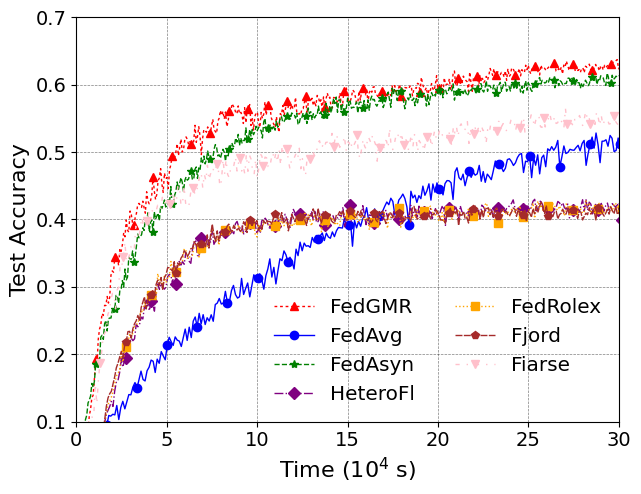

medium_iid


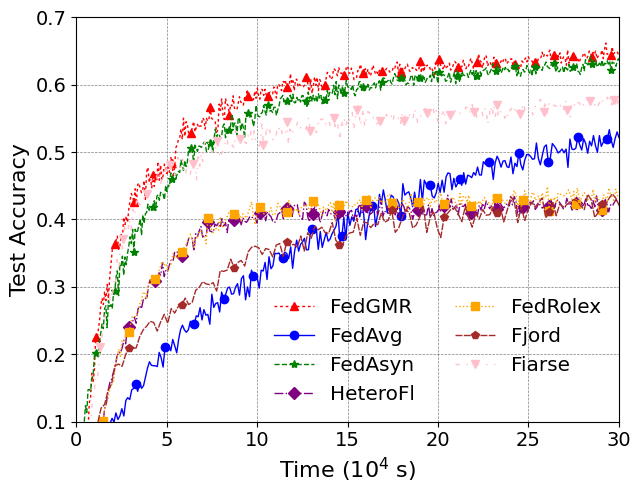

low_iid


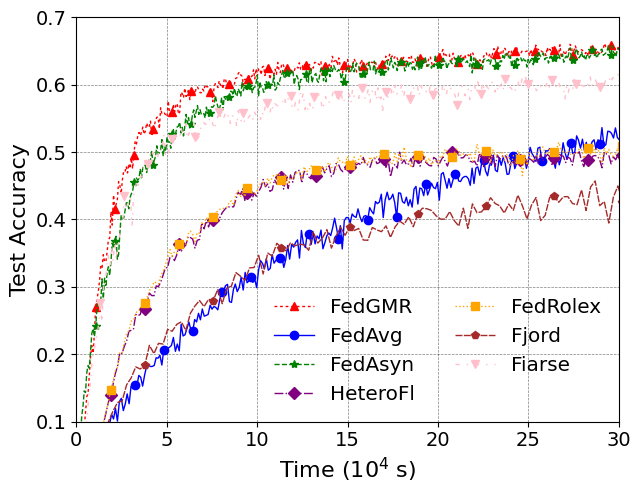

high_niid


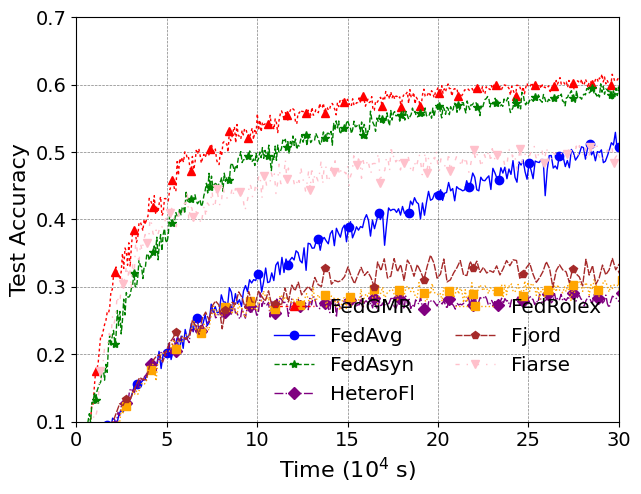

medium_niid


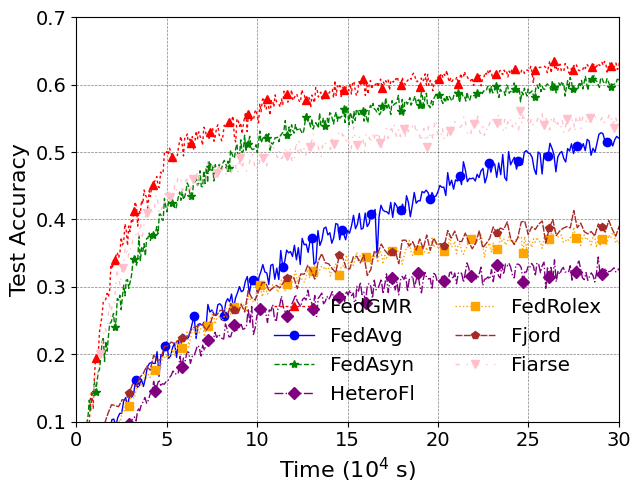

low_niid


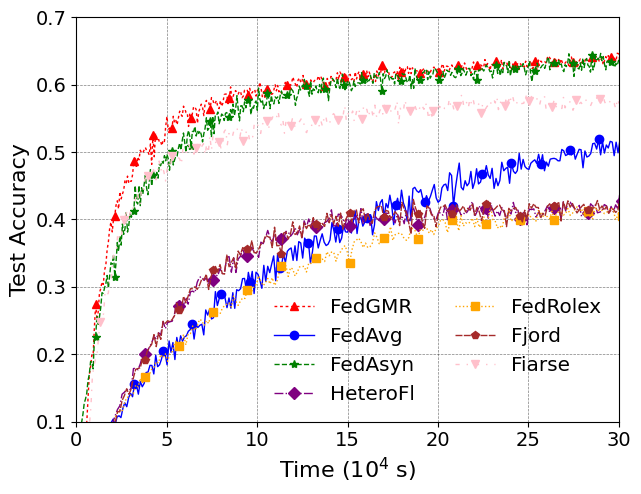

In [9]:
exp_list =sorted_list = [
    # iid_high 顺序
'iid_2.0_high_pr_fl_ImageNet100_15',
'iid_high__fed_avg_ImageNet100_7.5_5',
'iid_high__fed_asyn_ImageNet100_10_50_bp',
'iid_high_heterofl_ImageNet100',
'iid_high_fedrolex_ImageNet100',
 'iid_high_fjord_ImageNet100_bern',
'iid_high__fiarse_ImageNet100_10_w_50_bp',



        # iid_medium 按相同顺序
    'iid_2.0_medium_pr_fl_ImageNet100_15',
    'iid_medium__fed_avg_ImageNet100_7.5_5',
    'iid_medium__fed_asyn_ImageNet100_10_50_bp',
 'iid_medium_heterofl_ImageNet100',
'iid_medium_fedrolex_ImageNet100',
 'iid_medium_fjord_ImageNet100',
   'iid_medium__fiarse_ImageNet100_10_w_50_bp',


    # iid_low 按相同顺序
'iid_2.0_low_pr_fl_ImageNet100_7',
'iid_low__fed_avg_ImageNet100_7.5_5',
'iid_low__fed_asyn_ImageNet100_10_50_bp',
'iid_low_heterofl_ImageNet100',
'iid_low_fedrolex_ImageNet100',
'iid_low_fjord_ImageNet100',
'iid_low__fiarse_ImageNet100_10_w_50_bp',





    # niid_high 按相同顺序
'niid_2.0_high_pr_fl_ImageNet100_10',
'niid_high__fed_avg_ImageNet100_7.5_5',
'niid_high__fed_asyn_ImageNet100_10_50_bp',
'niid_high_heterofl_ImageNet100',
'niid_high_fedrolex_ImageNet100',
'niid_high_fjord_ImageNet100',
'niid_high__fiarse_ImageNet100_10_w_50_bp',




    # niid_medium 按相同顺序
    'niid_2.0_medium_pr_fl_ImageNet100_15',
    'niid_medium__fed_avg_ImageNet100_7.5_5',
    'niid_medium__fed_asyn_ImageNet100_10_50_bp',
 'niid_medium_heterofl_ImageNet100',
'niid_medium_fedrolex_ImageNet100',
 'niid_medium_fjord_ImageNet100',
    'niid_medium__fiarse_ImageNet100_10_w_50_bp',



    
    # niid_low 按相同顺序
        'niid_2.0_low_pr_fl_ImageNet100',
    'niid_low__fed_avg_ImageNet100_7.5_5',
    'niid_low__fed_asyn_ImageNet100_10_50_bp',
 'niid_low_heterofl_ImageNet100',
'niid_low_fedrolex_ImageNet100',
 'niid_low_fjord_ImageNet100_bern',
    'niid_low__fiarse_ImageNet100_10_w_50_bp',

]


fig_name_list = ['high_iid','medium_iid','low_iid','high_niid','medium_niid','low_niid',]
exp_legend = [
 'FedGMR',
 'FedAvg',
'FedAsyn',
'HeteroFl',
'FedRolex',
'Fjord',
 'Fiarse',
]


plt_time_acc(exp_list, 250000)
i = 0 
while i < len(exp_list):
    exp = exp_list[i:i+len(exp_legend)]
    fn = fig_name_list[int(i/len(exp_legend))]
    print(fn)
    fn = fn+'baseline'
    plt_photo_acc(exp,exp_legend,fig_name = fn,y_lim= [0.10,0.70],x_lim= [0,300000])
    i= i+len(exp_legend)
    



iid_2.0_high_pr_fl_ImageNet100 [5000, 5.08, '3.5']
iid_2.0_high_asyn_ImageNet100 [5000, 6.31, '3.8']
iid_high__gmr_ImageNet100_20_50_bp [5000, 5.77, '3.5']
iid_2.0_high_gradient_avg_ImageNet100 [5000, 9.71, '6']
iid_2.0_high_mask_fed_avg_ImageNet100 [5000, 11.84, '4.6']
iid_2.0_high_10_gradient_avg_ImageNet100 [5000, 10.13, '6.4']
iid_2.0_high_10_mask_fed_avg_ImageNet100 [5000, 11.96, '4.3']
iid_2.0_medium_pr_fl_ImageNet100 [5000, 7.33, '4.8']
iid_2.0_medium_asyn_ImageNet100 [5000, 7.97, '4.8']
iid_medium__gmr_ImageNet100_20_50_bp [5000, 6.3, '4.2']
iid_2.0_medium_gradient_avg_ImageNet100 [5000, 11.18, '6.5']
iid_2.0_medium_mask_fed_avg_ImageNet100 [5000, 12.57, '5.1']
iid_2.0_medium_10_gradient_avg_ImageNet100 [5000, 11.73, '6.9']
iid_2.0_medium_10_mask_fed_avg_ImageNet100 [5000, 12.11, '4.5']
iid_2.0_low_pr_fl_ImageNet100 [5000, 10.37, '6.2']
iid_2.0_low_asyn_ImageNet100 [5000, 9.91, '5.7']
iid_low__gmr_ImageNet100_20_50_bp [5000, 10.18, '6.2']
iid_2.0_low_gradient_avg_ImageNet100 [5

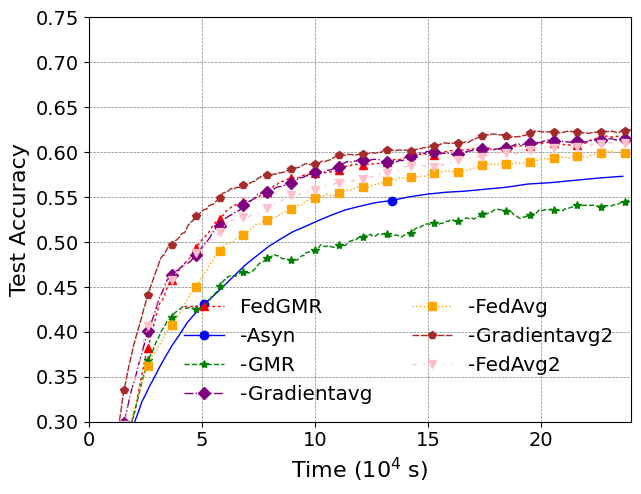

medium_iid


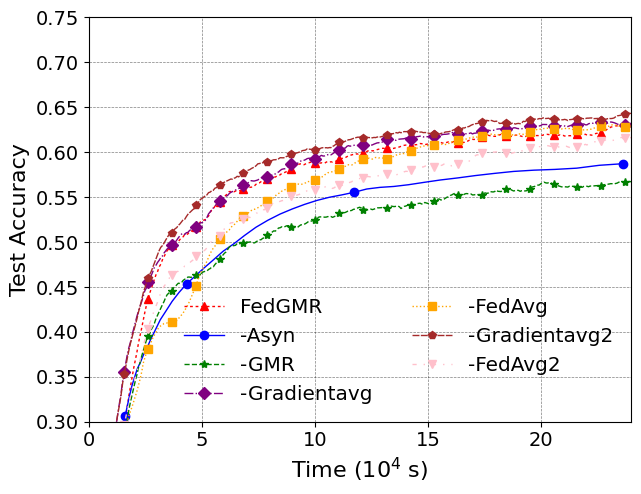

low_iid


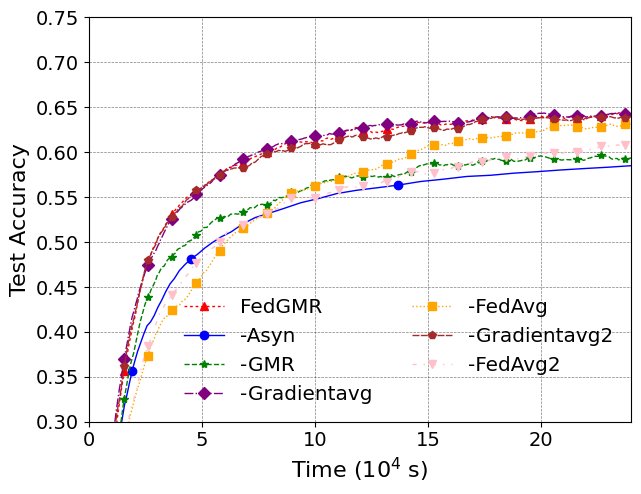

high_niid


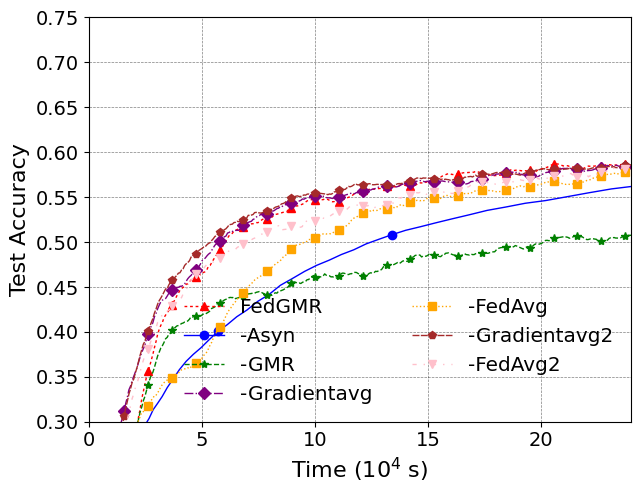

medium_niid


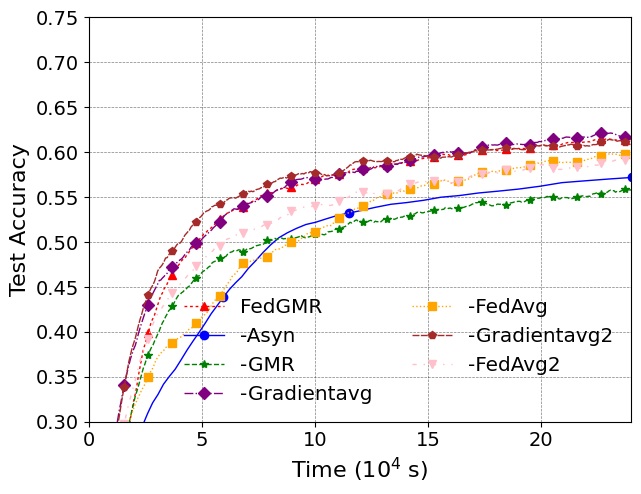

low_niid


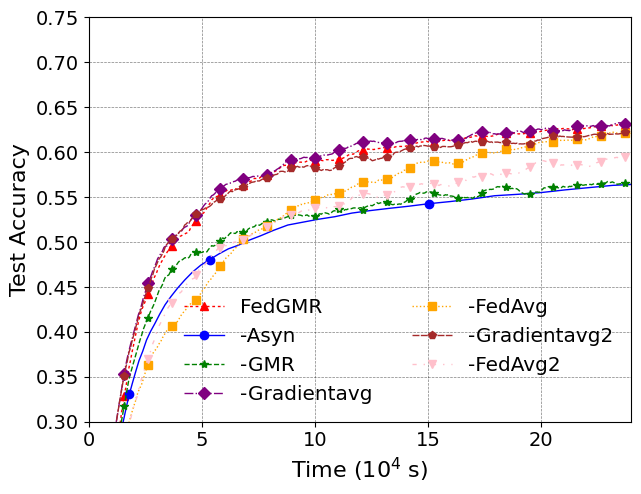

In [8]:
exp_list = [
 'iid_2.0_high_pr_fl_ImageNet100',
 'iid_2.0_high_asyn_ImageNet100',
'iid_high__gmr_ImageNet100_20_50_bp',
'iid_2.0_high_gradient_avg_ImageNet100',
'iid_2.0_high_mask_fed_avg_ImageNet100',
'iid_2.0_high_10_gradient_avg_ImageNet100',
'iid_2.0_high_10_mask_fed_avg_ImageNet100',
    
'iid_2.0_medium_pr_fl_ImageNet100',
 'iid_2.0_medium_asyn_ImageNet100',
'iid_medium__gmr_ImageNet100_20_50_bp',
 'iid_2.0_medium_gradient_avg_ImageNet100',
 'iid_2.0_medium_mask_fed_avg_ImageNet100',
 'iid_2.0_medium_10_gradient_avg_ImageNet100',
 'iid_2.0_medium_10_mask_fed_avg_ImageNet100',
    
 'iid_2.0_low_pr_fl_ImageNet100',
 'iid_2.0_low_asyn_ImageNet100',
'iid_low__gmr_ImageNet100_20_50_bp',
 'iid_2.0_low_gradient_avg_ImageNet100',
 'iid_2.0_low_mask_fed_avg_ImageNet100',
 'iid_2.0_low_10_gradient_avg_ImageNet100',
 'iid_2.0_low_10_mask_fed_avg_ImageNet100',
    
 'niid_2.0_high_pr_fl_ImageNet100',
 'niid_2.0_high_asyn_ImageNet100',
'niid_high__gmr_ImageNet100_20_50_bp',
 'niid_2.0_high_gradient_avg_ImageNet100',
 'niid_2.0_high_mask_fed_avg_ImageNet100',
 'niid_2.0_high_10_gradient_avg_ImageNet100',
 'niid_2.0_high_10_mask_fed_avg_ImageNet100',
    
'niid_2.0_medium_pr_fl_ImageNet100',
 'niid_2.0_medium_asyn_ImageNet100',
'niid_medium__gmr_ImageNet100_20_50_bp',
 'niid_2.0_medium_gradient_avg_ImageNet100',
 'niid_2.0_medium_mask_fed_avg_ImageNet100',
 'niid_2.0_medium_10_gradient_avg_ImageNet100',
 'niid_2.0_medium_10_mask_fed_avg_ImageNet100',
    
'niid_2.0_low_pr_fl_ImageNet100',
'niid_2.0_low_asyn_ImageNet100',
'niid_low__gmr_ImageNet100_20_50_bp',
'niid_2.0_low_gradient_avg_ImageNet100',
'niid_2.0_low_mask_fed_avg_ImageNet100',
'niid_2.0_low_10_gradient_avg_ImageNet100',
'niid_2.0_low_10_mask_fed_avg_ImageNet100',
    
]


fig_name_list = ['high_iid','medium_iid','low_iid','high_niid','medium_niid','low_niid',]

exp_legend = ['FedGMR',
 '-Asyn',
 '-GMR',
 '-Gradientavg',
'-FedAvg',
 '-Gradientavg2',
'-FedAvg2']

plt_time_acc(exp_list, 5000)
plt_time_acc(exp_list, 250000)
i = 0 
while i < len(exp_list):
    exp = exp_list[i:i+len(exp_legend)]
    fn = fig_name_list[int(i/len(exp_legend))]
    print(fn)
    fn = fn+'Ablation'
    plt_photo_acc(exp,exp_legend,fig_name = fn,y_lim= [0.3,0.75],x_lim= [0,240000], cov='True')
    i= i+len(exp_legend)
    



iid_2.0_high_pr_fl_ImageNet100_1 [100000, 52.33, '1.4']
iid_2.0_high_pr_fl_ImageNet100_2 [100000, 54.76, '0.62']
iid_2.0_high_pr_fl_ImageNet100 [100000, 57.63, '0.6']
iid_2.0_high_pr_fl_ImageNet100_7 [100000, 57.11, '0.94']
iid_2.0_high_pr_fl_ImageNet100_10 [100000, 57.65, '0.73']
iid_2.0_high_pr_fl_ImageNet100_15 [100000, 54.8, '0.91']
iid_2.0_high_pr_fl_ImageNet100_20 [100000, 54.92, '0.98']
iid_2.0_medium_pr_fl_ImageNet100_1 [100000, 54.68, '1.4']
iid_2.0_medium_pr_fl_ImageNet100_2 [100000, 57.16, '0.57']
iid_2.0_medium_pr_fl_ImageNet100 [100000, 58.79, '0.55']
iid_2.0_medium_pr_fl_ImageNet100_7 [100000, 58.47, '0.29']
iid_2.0_medium_pr_fl_ImageNet100_10 [100000, 58.98, '0.38']
iid_2.0_medium_pr_fl_ImageNet100_15 [100000, 58.51, '0.65']
iid_2.0_medium_pr_fl_ImageNet100_20 [100000, 58.47, '0.72']
iid_2.0_low_pr_fl_ImageNet100_1 [100000, 59.27, '0.99']
iid_2.0_low_pr_fl_ImageNet100_2 [100000, 60.49, '0.49']
iid_2.0_low_pr_fl_ImageNet100 [100000, 61.08, '0.6']
iid_2.0_low_pr_fl_ImageNe

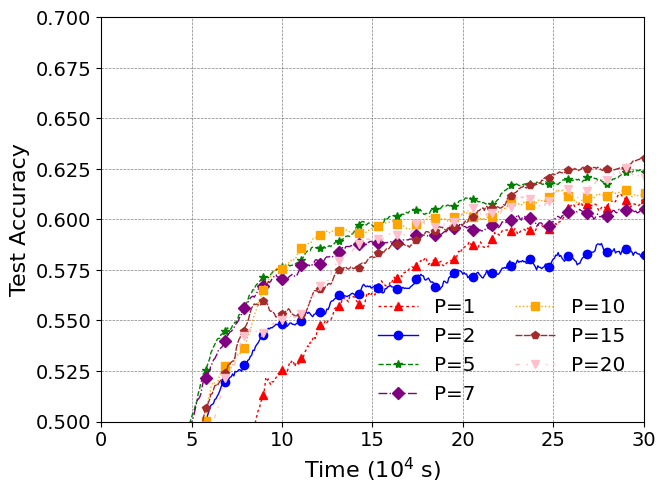

medium_iid


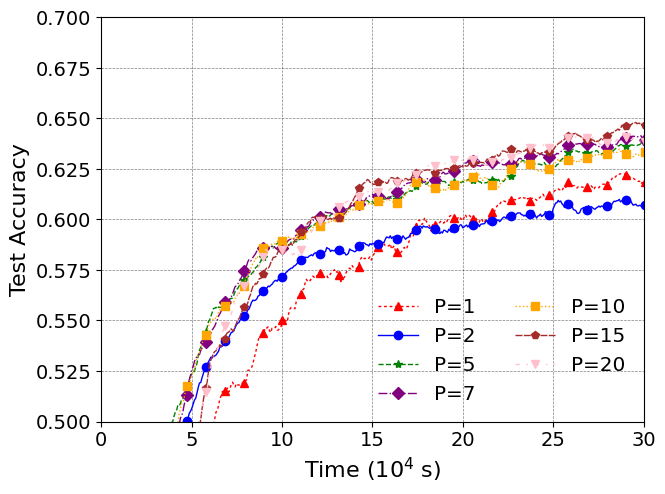

low_iid


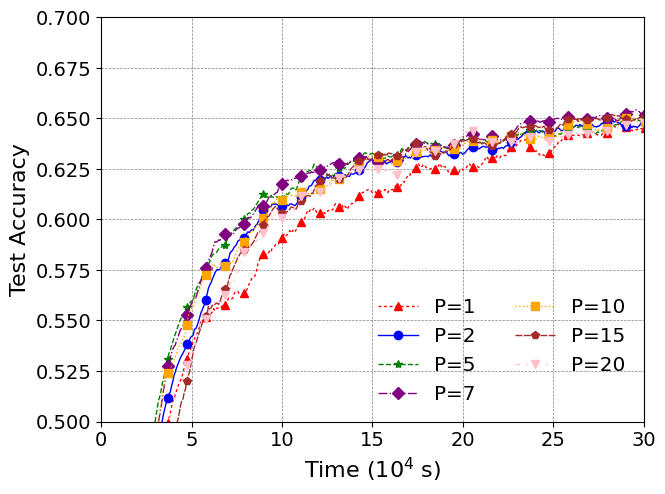

high_niid


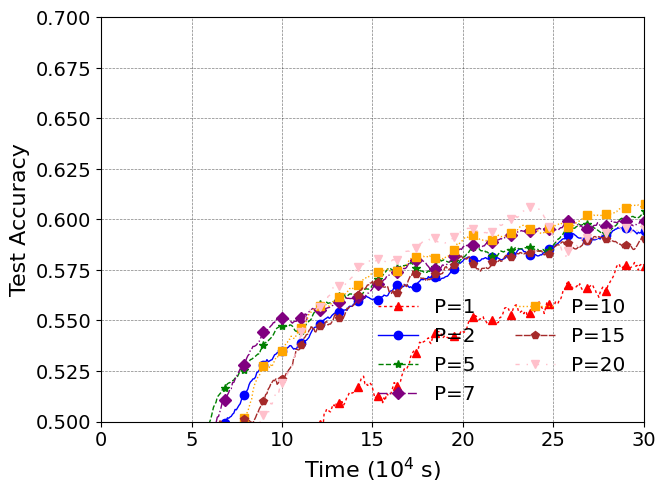

medium_niid


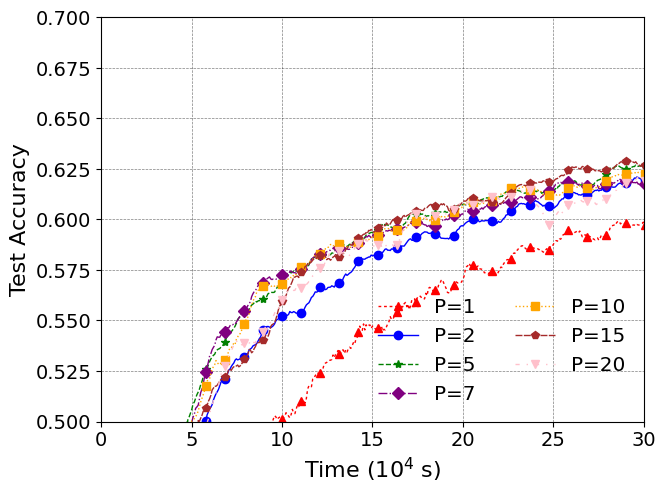

low_niid


In [ ]:
exp_list = [
    'iid_2.0_high_pr_fl_ImageNet100_1',
    'iid_2.0_high_pr_fl_ImageNet100_2',
    'iid_2.0_high_pr_fl_ImageNet100',
    'iid_2.0_high_pr_fl_ImageNet100_7',
    'iid_2.0_high_pr_fl_ImageNet100_10',
    'iid_2.0_high_pr_fl_ImageNet100_15',
    'iid_2.0_high_pr_fl_ImageNet100_20',

    'iid_2.0_medium_pr_fl_ImageNet100_1',
    'iid_2.0_medium_pr_fl_ImageNet100_2',
    'iid_2.0_medium_pr_fl_ImageNet100',
    'iid_2.0_medium_pr_fl_ImageNet100_7',
    'iid_2.0_medium_pr_fl_ImageNet100_10',
    'iid_2.0_medium_pr_fl_ImageNet100_15',
    'iid_2.0_medium_pr_fl_ImageNet100_20',

    'iid_2.0_low_pr_fl_ImageNet100_1',
    'iid_2.0_low_pr_fl_ImageNet100_2',
    'iid_2.0_low_pr_fl_ImageNet100',
    'iid_2.0_low_pr_fl_ImageNet100_7',
    'iid_2.0_low_pr_fl_ImageNet100_10',
    'iid_2.0_low_pr_fl_ImageNet100_15',
    'iid_2.0_low_pr_fl_ImageNet100_20',

    'niid_2.0_high_pr_fl_ImageNet100_1',
    'niid_2.0_high_pr_fl_ImageNet100_2',
    'niid_2.0_high_pr_fl_ImageNet100',
    'niid_2.0_high_pr_fl_ImageNet100_7',
    'niid_2.0_high_pr_fl_ImageNet100_10',
    'niid_2.0_high_pr_fl_ImageNet100_15',
    'niid_2.0_high_pr_fl_ImageNet100_20',

    'niid_2.0_medium_pr_fl_ImageNet100_1',
    'niid_2.0_medium_pr_fl_ImageNet100_2',
    'niid_2.0_medium_pr_fl_ImageNet100',
    'niid_2.0_medium_pr_fl_ImageNet100_7',
    'niid_2.0_medium_pr_fl_ImageNet100_10',
    'niid_2.0_medium_pr_fl_ImageNet100_15',
    'niid_2.0_medium_pr_fl_ImageNet100_20',

    'niid_2.0_low_pr_fl_ImageNet100_1',
    'niid_2.0_low_pr_fl_ImageNet100_2',
    'niid_2.0_low_pr_fl_ImageNet100',
    'niid_2.0_low_pr_fl_ImageNet100_7',
    'niid_2.0_low_pr_fl_ImageNet100_10',
    'niid_2.0_low_pr_fl_ImageNet100_15',
    'niid_2.0_low_pr_fl_ImageNet100_20',
]


fig_name_list = ['high_iid','medium_iid','low_iid','high_niid','medium_niid','low_niid',]

exp_legend = ['P=1','P=2','P=5','P=7','P=10','P=15','P=20',]


plt_time_acc(exp_list, 100000)
plt_time_acc(exp_list, 250000)
i = 0 
while i < len(exp_list):
    exp = exp_list[i:i+len(exp_legend)]
    fn = fig_name_list[int(i/len(exp_legend))]
    print(fn)
    fn = fn+'patience'
    plt_photo_acc(exp,exp_legend,fig_name = fn,y_lim= [0.5,0.70],x_lim= [0,300000], cov = True)
    i= i+len(exp_legend)
    

